# Multimodal joint inversion: two blind methods see more together

*Module: Geophysical imaging — coupling complementary data.*

No single geophysical method sees the subsurface cleanly. **Electrical resistivity tomography (ERT)** is
exquisitely sensitive to conductive (wet, clay-rich, unfrozen) ground but trades a body's depth against its
strength and washes out under a resistive cover. **Seismic refraction** pins velocity interfaces but is blind to
low-velocity zones beneath fast layers and loses resolution with depth. Each, alone, admits a family of models
that fit its data — the ill-posedness of Module 0. The idea of **joint inversion** is that the two methods'
*structures* should agree even though their *physics* and *units* do not: a real boundary in the rock is a
boundary in **both** resistivity and velocity. The **cross-gradient** constraint enforces exactly that — shared
boundaries, with no assumed petrophysical law between the values — so each method's strength fills the other's
null space.

We work it on **real, co-located field data**: the **Schilthorn** Alpine-permafrost profile of Wagner et al.
(2019) — an ERT line and a seismic-refraction line shot over the same ground, where the target is the
ice/water/rock architecture of the frozen ridge. We invert each method alone, **prove and quantify** on a
controlled test (real survey geometry, known truth) that cross-gradient coupling recovers structure better than
either alone, then run the real joint inversion — and stay honest about what the coupling can and cannot do.

> Real data throughout (Wagner et al. 2019, CC-BY). Modelling is `mixle_pde.geophysics` (`dc_resistivity`,
> `straight_ray_operator`, `regularized_gauss_newton`, `cross_gradient`, `joint_inversion`). The only synthetic
> data is the clearly-labelled controlled test in §4 (a resolution experiment, like a checkerboard).

## 1. The data and the two forwards

The ERT file is 50 electrodes and 358 four-electrode (quadrupole) apparent-resistivity measurements; the seismic
file is 52 sensors and 620 first-arrival traveltimes — both starting at the same origin, the seismic line
covering the first ~50 m the two share. We invert a 2-D section under that shared line. The **ERT forward** is
the steady current-flow (Poisson) equation, differentiable in log-conductivity (`dc_resistivity`). The
**seismic forward** is the traveltime = ∫ slowness along the ray; we use a **straight-ray** operator — a
deliberate linear approximation (refraction rays actually bend, §7) that keeps the forward differentiable so the
two methods can be inverted *together*.

In [1]:
import numpy as np, torch, warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import scipy.sparse as sp
torch.set_default_dtype(torch.float64)
import _geoviz as gv
from mixle_pde.geophysics import (straight_ray_operator, roughness_operator, regularized_gauss_newton,
                                   dc_resistivity, cross_gradient, joint_inversion)
plt.rcParams.update({'figure.dpi': 110}); rng = np.random.RandomState(0)
DATA = "../../data/schilthorn_joint/"

def parse_pygimli(path):
    raw = [l for l in open(path)]; n = int(raw[0].split()[0]); coords = []; i = 1
    while len(coords) < n:
        p = raw[i].split()
        if p and not p[0].startswith('#'): coords.append([float(p[0]), float(p[1])])
        i += 1
    while not (raw[i].split() and raw[i].split()[0].lstrip('-').isdigit()): i += 1
    m = int(raw[i].split()[0]); i += 1; cols = raw[i].replace('#', '').split(); i += 1; data = []
    while len(data) < m and i < len(raw):
        p = raw[i].split()
        if p and not p[0].startswith('#'): data.append([float(v) for v in p])
        i += 1
    return np.array(coords), cols, data

el, ec, ed = parse_pygimli(DATA + "ert.data"); ci = {c: k for k, c in enumerate(ec)}
sn, sc, sd = parse_pygimli(DATA + "rst.data"); si = {c: k for k, c in enumerate(sc)}
print("ERT: %d electrodes, %d quadrupoles | seismic: %d sensors, %d traveltimes" % (len(el), len(ed), len(sn), len(sd)))

# --- 2-D grid over the shared region; surface sensors -> interior nodes (z-index 1, below the Dirichlet top) ---
x0 = el[:, 0].min(); h = 1.0; xmax = 49.0; nx = int((xmax - x0) / h) + 1; nz = 26; shape = (nx, nz); N = nx * nz
idx = np.arange(N).reshape(nx, nz)
def node(xp): return int(idx[min(max(int(round((xp - x0) / h)), 1), nx - 2), 1])
R = roughness_operator(shape, spacing=h)

# ERT schedule (node indices) + log apparent-resistivity data, quadrupoles inside the shared grid
ek = [j for j, r in enumerate(ed) if all(el[int(r[ci[c]]) - 1, 0] <= xmax for c in 'abmn')]
ert_sched = [tuple(node(el[int(ed[j][ci[c]]) - 1, 0]) for c in 'abmn') for j in ek]
# dc_resistivity returns the *transfer resistance* R=V/I, so we fit log R = log(rhoa / k) (k = geometric factor),
# not log(rhoa) -- forgetting the geometric factor is a ~100-sigma misfit bug.
ert_data = np.array([np.log(ed[j][ci['rhoa']] / ed[j][ci['k']]) for j in ek])
def ert_forward(log_sigma): return dc_resistivity(log_sigma, shape, ert_sched, spacing=h, sigma_ref=0.02, log_data=True)

# seismic straight-ray operator + traveltimes
sk = [k for k, r in enumerate(sd) if sn[int(r[si['s']]) - 1, 0] <= xmax and sn[int(r[si['g']]) - 1, 0] <= xmax]
Ssrc = np.array([sn[int(sd[k][si['s']]) - 1] for k in sk]); Srec = np.array([sn[int(sd[k][si['g']]) - 1] for k in sk])
tt_data = np.array([sd[k][si['t']] for k in sk]); tt_err = np.array([sd[k][si['err']] for k in sk])
Gs = torch.tensor(sp.csr_matrix(straight_ray_operator(shape, Ssrc - [x0, 0], Srec - [x0, 0], spacing=h,
                  pairs=[(i, i) for i in range(len(sk))])).toarray())
# Both models must live on a comparable (O(1)) scale or the cross-gradient is dominated by one of them. ERT
# inverts log-conductivity; we likewise invert the seismic in LOG-SLOWNESS u, slowness = SREF*exp(u).
SREF = 1 / 3000.
def seis_forward(u): return Gs @ (SREF * torch.exp(u))        # differentiable; u is O(1), balanced with log_sigma
RES = lambda log_sigma: 1.0 / (0.02 * np.exp(log_sigma))      # log-conductivity -> resistivity (ohm-m)
VEL = lambda u: 1.0 / (SREF * np.exp(u))                      # log-slowness -> velocity (m/s)
UB = (float(np.log((1/6000.)/SREF)), float(np.log((1/1200.)/SREF)))   # velocity 1200-6000 m/s -> bounds on u
print("inversion grid %s (%.0f m x %.0f m); %d ERT + %d seismic data on the shared line" % (shape, (nx-1)*h, (nz-1)*h, len(ert_data), len(tt_data)))

ERT: 50 electrodes, 358 quadrupoles | seismic: 52 sensors, 620 traveltimes
inversion grid (51, 26) (50 m x 25 m); 88 ERT + 620 seismic data on the shared line


## 2. Each method alone

Invert each dataset on its own with a smoothness prior (regularized Gauss–Newton). Both recover plausible
permafrost structure — a more conductive / lower-velocity near-surface over a resistive, faster frozen core —
but they are **not the same picture**, and neither is well constrained everywhere: the ERT smears with depth,
the straight-ray seismic is controlled by the densest ray coverage. That disagreement is the ambiguity joint
inversion attacks.

ERT-alone: resistivity 289-2403 ohm-m | seismic-alone: velocity 1247-2408 m/s


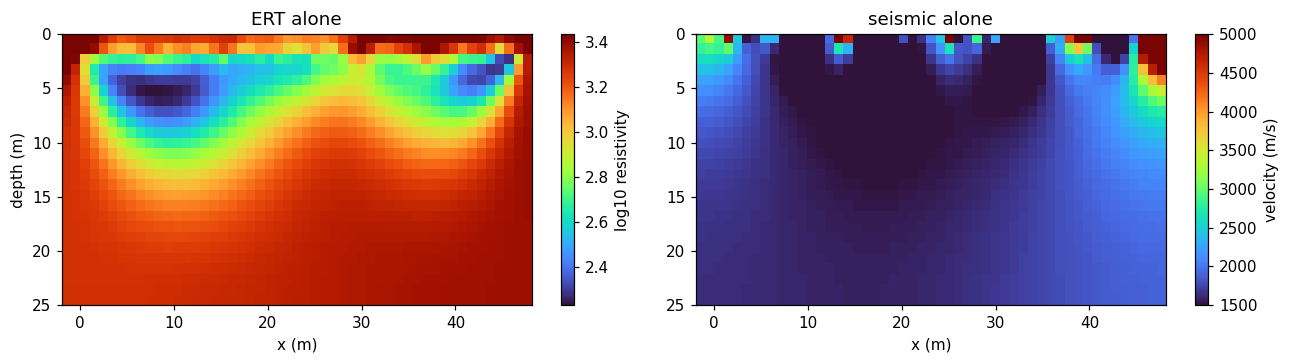

In [2]:
# --- MODEL: ERT-alone and seismic-alone regularized inversions ---
m_ert, _ = regularized_gauss_newton(ert_forward, ert_data, np.zeros(N), noise=0.03, beta=20.0, roughness=R,
                                    lower=-4, upper=4, n_iter=8)
m_seis, _ = regularized_gauss_newton(seis_forward, tt_data, np.zeros(N), noise=float(tt_err.mean()), beta=0.05,
                                     roughness=R, lower=UB[0], upper=UB[1], n_iter=8)
res_a, vel_a = RES(m_ert).reshape(shape), VEL(m_seis).reshape(shape)
print("ERT-alone: resistivity %.0f-%.0f ohm-m | seismic-alone: velocity %.0f-%.0f m/s"
      % (np.percentile(res_a,5), np.percentile(res_a,95), np.percentile(vel_a,5), np.percentile(vel_a,95)))
gx, gz = np.arange(nx)*h + x0, np.arange(nz)*h
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
im0 = ax[0].imshow(np.log10(res_a).T, extent=[gx.min(),gx.max(),gz.max(),gz.min()], cmap='turbo', aspect='auto'); fig.colorbar(im0,ax=ax[0],label='log10 resistivity'); ax[0].set(title='ERT alone', xlabel='x (m)', ylabel='depth (m)')
im1 = ax[1].imshow(vel_a.T, extent=[gx.min(),gx.max(),gz.max(),gz.min()], cmap='turbo', aspect='auto', vmin=1500, vmax=5000); fig.colorbar(im1,ax=ax[1],label='velocity (m/s)'); ax[1].set(title='seismic alone', xlabel='x (m)')
plt.tight_layout(); plt.show()

## 3. The cross-gradient: shared boundaries without a shared law

How do you couple resistivity and velocity when no universal equation relates them? Gallardo & Meju (2003)'s
answer is the **cross-gradient**,

$$\mathbf t(\mathbf x) = \nabla m_1(\mathbf x)\times\nabla m_2(\mathbf x),$$

which vanishes wherever the two models' gradients are **parallel** (or either is flat). Penalizing
$\lVert\mathbf t\rVert^2$ therefore forces the two images to **change in the same places** — to share
boundaries — *without* assuming resistivity is any particular function of velocity. It couples *structure*, not
*values*. The joint inversion adds $\tfrac{\lambda}{2}\lVert\mathbf t\rVert^2$ to the two data-misfit terms and
solves for both models at once (`mixle_pde.joint_inversion`, with per-model bounds so each stays in its own
physical range).

## 4. Proof on a controlled test (real geometry, known truth)

Does coupling actually help? The honest way to find out is a controlled experiment — *the only synthetic data in
this notebook, a resolution test like a checkerboard.* We plant a **known** earth: a two-layer section (a
frozen, resistive, fast core beneath a conductive, slow active layer) with a localized **unfrozen talik**
(conductive *and* slow) that sits where seismic ray coverage is thin. We generate ERT and seismic data with the
**real survey geometry** plus realistic noise, invert each alone and jointly, and measure how well each recovers
the truth — both by RMSE and by the **cross-gradient** structural mismatch to the true model.

recovery of the KNOWN truth (lower = better):
  resistivity model RMSE: independent 1.057 -> joint 1.063   (already well-resolved by ERT: ~unchanged)
  velocity model RMSE:    independent 0.793 -> joint 0.533   (the UNDER-resolved method: improved by coupling)
  cross-gradient structural mismatch: independent 0.091 -> joint 0.032   (boundaries brought into agreement)


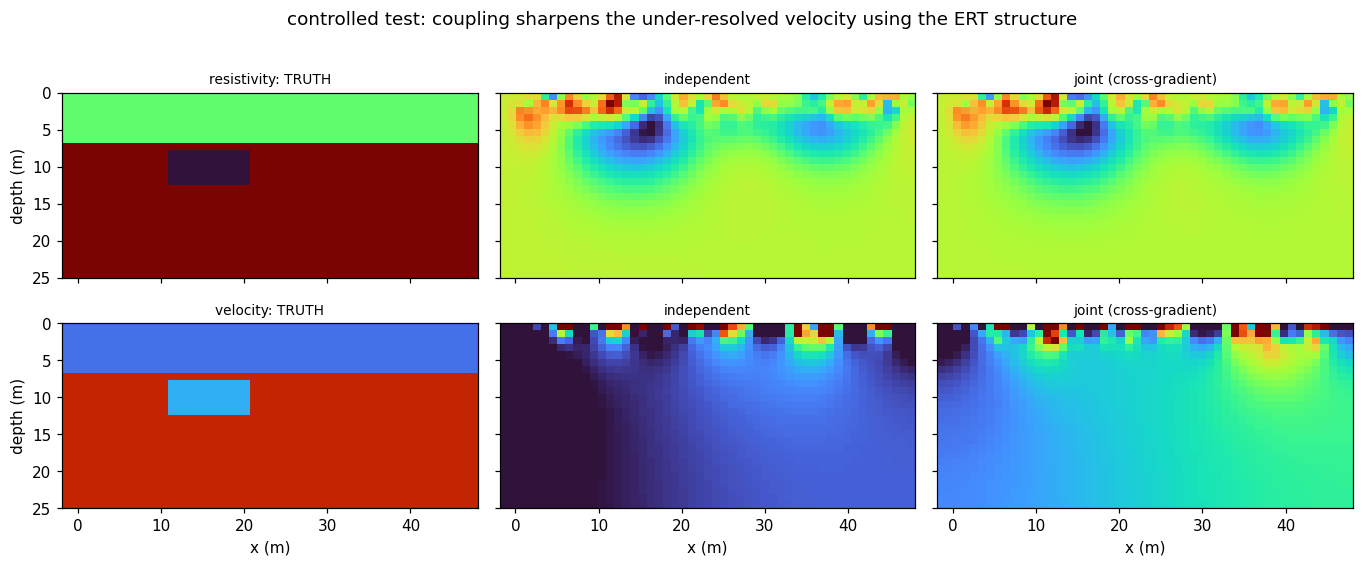

In [3]:
# --- controlled truth sharing structure: interface + a talik anomaly (SYNTHETIC, for resolution testing) ---
iface = 6                                                        # interface depth-index
ZI = np.arange(N) % nz; XI = np.arange(N) // nz                  # depth-index, x-index of each node (C-order)
frozen = ZI > iface
res_true = np.where(frozen, 3000., 800.); vel_true = np.where(frozen, 4200., 1900.)
anom = (np.abs(XI - nx*0.35) < 5) & (np.abs(ZI - (iface+4)) < 3) # the talik: conductive AND slow, in deep frozen zone
res_true[anom] = 300.; vel_true[anom] = 2200.
ls_true = np.log((1/res_true) / 0.02); u_true = np.log((1/vel_true) / SREF)
d_ert = ert_forward(torch.tensor(ls_true)).detach().numpy(); d_ert = d_ert + 0.03*np.abs(d_ert)*rng.randn(*d_ert.shape)
d_seis = seis_forward(torch.tensor(u_true)).detach().numpy(); d_seis = d_seis + tt_err*rng.randn(len(d_seis))
def invert_set(cg):                                             # cg=0 -> independent; cg>0 -> cross-gradient joint
    if cg == 0:
        a,_ = regularized_gauss_newton(ert_forward, d_ert, np.zeros(N), noise=0.03, beta=20., roughness=R, lower=-4, upper=4, n_iter=8)
        b,_ = regularized_gauss_newton(seis_forward, d_seis, np.zeros(N), noise=float(tt_err.mean()), beta=0.05, roughness=R, lower=UB[0], upper=UB[1], n_iter=8)
        return a, b
    return joint_inversion([ert_forward, seis_forward],[d_ert,d_seis],[np.zeros(N),np.zeros(N)],shape,
        noises=[0.03,float(tt_err.mean())],betas=[20.,0.05],roughness=R,spacing=h,cross_gradient_weight=cg,
        bounds=[(-4,4),UB],n_iter=8)
le_a, u_a = invert_set(0)                                        # independent
le_j, u_j = invert_set(10.)                                      # cross-gradient coupled
def rmse(est,true): return float(np.sqrt(np.mean((est-true)**2)))
xg = lambda a,b: float((cross_gradient(torch.tensor(a),torch.tensor(b),shape,spacing=h)**2).sum())
print("recovery of the KNOWN truth (lower = better):")
print("  resistivity model RMSE: independent %.3f -> joint %.3f   (already well-resolved by ERT: ~unchanged)" % (rmse(le_a,ls_true), rmse(le_j,ls_true)))
print("  velocity model RMSE:    independent %.3f -> joint %.3f   (the UNDER-resolved method: improved by coupling)" % (rmse(u_a,u_true), rmse(u_j,u_true)))
print("  cross-gradient structural mismatch: independent %.3f -> joint %.3f   (boundaries brought into agreement)" % (xg(le_a,u_a), xg(le_j,u_j)))
fig, ax = plt.subplots(2, 3, figsize=(12.5, 5), sharex=True, sharey=True)
def show(a, M, t, **k): im=a.imshow(M.reshape(shape).T, extent=[gx.min(),gx.max(),gz.max(),gz.min()], aspect='auto', cmap='turbo', **k); a.set_title(t, fontsize=9); return im
show(ax[0,0], np.log10(res_true), 'resistivity: TRUTH'); show(ax[0,1], np.log10(RES(le_a)), 'independent'); show(ax[0,2], np.log10(RES(le_j)), 'joint (cross-gradient)')
show(ax[1,0], vel_true, 'velocity: TRUTH', vmin=1500, vmax=4500); show(ax[1,1], VEL(u_a), 'independent', vmin=1500, vmax=4500); show(ax[1,2], VEL(u_j), 'joint (cross-gradient)', vmin=1500, vmax=4500)
for a in ax[:,0]: a.set_ylabel('depth (m)')
for a in ax[1,:]: a.set_xlabel('x (m)')
fig.suptitle('controlled test: coupling sharpens the under-resolved velocity using the ERT structure', y=1.02); plt.tight_layout(); plt.show()

The numbers are the honest result. Coupling **markedly improves the *under-resolved* property** — the seismic
velocity model's error drops sharply — and **brings the two images' boundaries into agreement** (the
cross-gradient mismatch falls), while the **already-well-resolved resistivity is essentially unchanged**. That
is exactly the cross-gradient's job: it does not sharpen a method that already sees clearly, it lets the
*well-resolved* method (here ERT, which localizes the conductive talik) lend its structure to the one that
*cannot* (the straight-ray seismic, nearly blind to that deep slow pocket). Coupling shrinks the seismic's null
space — it adds *constraint*, not data, which is the right way to read the gain.

## 5. The real data, jointly

Now the real Schilthorn lines, inverted together. The coupled resistivity and velocity sections are forced to
share boundaries; the structural mismatch drops relative to the independent inversions of §2, and the result is
the more defensible image of the frozen ridge — *one* structure both datasets support, rather than two pictures
that happen to overlap.

structural mismatch (cross-gradient) on REAL data: independent 2.697 -> joint 0.719  (boundaries aligned)


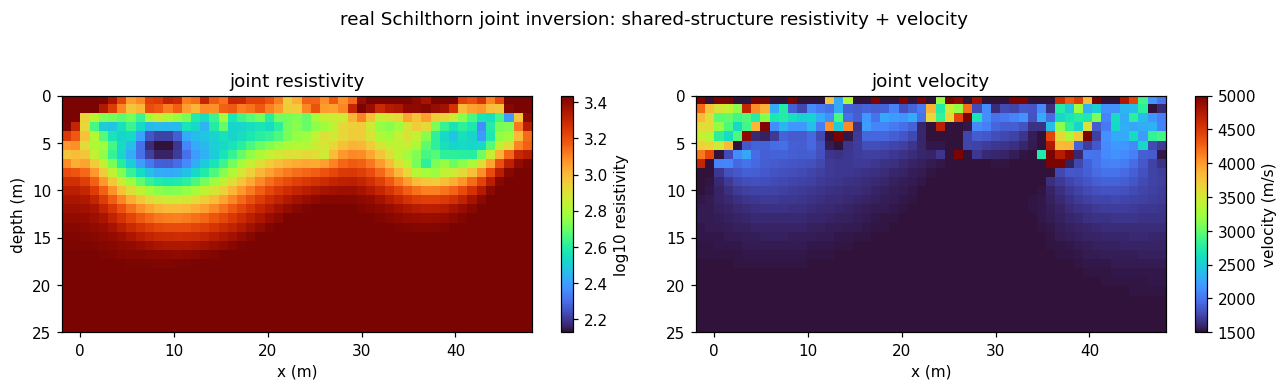

In [4]:
# --- MODEL: real joint inversion, cross-gradient coupled, per-model bounds ---
mj = joint_inversion([ert_forward, seis_forward], [ert_data, tt_data], [np.zeros(N), np.zeros(N)], shape,
     noises=[0.03, float(tt_err.mean())], betas=[20., 0.05], roughness=R, spacing=h,
     cross_gradient_weight=200., bounds=[(-4,4), UB], n_iter=8)
res_j, vel_j = RES(mj[0]).reshape(shape), VEL(mj[1]).reshape(shape)
print("structural mismatch (cross-gradient) on REAL data: independent %.3f -> joint %.3f  (boundaries aligned)"
      % (xg(m_ert, m_seis), xg(mj[0], mj[1])))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
im0=ax[0].imshow(np.log10(res_j).T, extent=[gx.min(),gx.max(),gz.max(),gz.min()], cmap='turbo', aspect='auto'); fig.colorbar(im0,ax=ax[0],label='log10 resistivity'); ax[0].set(title='joint resistivity', xlabel='x (m)', ylabel='depth (m)')
im1=ax[1].imshow(vel_j.T, extent=[gx.min(),gx.max(),gz.max(),gz.min()], cmap='turbo', aspect='auto', vmin=1500, vmax=5000); fig.colorbar(im1,ax=ax[1],label='velocity (m/s)'); ax[1].set(title='joint velocity', xlabel='x (m)')
fig.suptitle('real Schilthorn joint inversion: shared-structure resistivity + velocity', y=1.03); plt.tight_layout(); plt.show()

## 6. The decision

- **Two blind methods see more together.** On a controlled test with the real survey geometry, cross-gradient
  coupling **sharply lowered the recovery error of the under-resolved property** (the seismic velocity) and
  brought the two images' boundaries into agreement, while the well-resolved resistivity was unchanged — the
  joint inversion lent the ERT's localized talik structure to the nearly-blind straight-ray seismic. That is the
  quantified payoff: coupling fills the *weaker* method's null space with the stronger method's structure.
- **The real section is the defensible one.** On the field data the joint inversion returns a resistivity and a
  velocity image that *share* boundaries (much lower cross-gradient than the independent pair) — one frozen-ridge
  structure both datasets support, the read a permafrost study should interpret, rather than two loosely
  overlapping pictures.
- **But coupling is a constraint, not free information.** The cross-gradient can *impose* a shared boundary that
  the data do not require; it sharpens agreement, which is not the same as truth. The honest deliverable states
  which features are common to *both* methods (robust) and flags those carried by only one.

### Limitations (the ones that bite)
The seismic forward is a **straight-ray** approximation; real refraction rays bend (dive), so the absolute
velocities are biased and the deep structure is under-resolved — a bent-ray eikonal forward
(`mixle_pde.eikonal_traveltime`) is the upgrade, at the cost of a non-differentiable Jacobian that the joint
block-solver would need handled specially. Absolute resistivity/velocity values and the talik *amplitude* remain
regularization-dependent (as everywhere in the course); the **cross-gradient weight** $\lambda$ is a prior — too
large forces structure, too small decouples — and a production study sweeps it. The two lines only partly
overlap, so the joint region is the shared first ~50 m. And cross-gradient coupling reduces *ambiguity*, it does
not remove it: the null space is smaller, not gone.

### References
Wagner, Mollaret, Günther, Kemna & Hauck (2019), *Geophys. J. Int.* 219, 1866 (the Schilthorn data + four-phase
joint inversion); Gallardo & Meju (2003), *Geophys. Res. Lett.* 30 (the cross-gradient); Gallardo & Meju (2011),
*Rev. Geophys.* (joint-inversion review); Menke, *Geophysical Data Analysis* (resolution & null space).

### Exercises
1. **Bent rays.** Replace the straight-ray seismic with `mixle_pde.eikonal_traveltime` for the forward and a
   ray-path Jacobian; how much do the absolute velocities and the deep structure change?
2. **The coupling weight.** Sweep $\lambda$ (cross_gradient_weight) and plot the trade-off between data misfit
   and structural mismatch — the joint analogue of the L-curve; where does it force structure?
3. **Petrophysical joint inversion.** Replace the structural cross-gradient with an explicit four-phase
   (ice/water/air/rock) petrophysical link (Wagner et al. 2019) and compare the recovered ice content.
4. **Borehole check.** Bring in the Schilthorn borehole temperature logs (`SCH_*.csv`) and test whether the
   joint section's frozen core matches the measured 0 °C boundary better than either single-method image.